In [ ]:

import numpy as np
import cv2
import json

from itertools import groupby
from typing import List, Tuple, Dict, Any


def preprocess_image(image_path: str) -> np.ndarray:
    """Load Image, convert to grayscale, apply adaptive thresholding."""
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    binary = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    return binary


def detect_line_segments(binary: np.ndarray) -> List[Tuple[int, int]]:
    edges = cv2.Canny(binary, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=180, minLineLength=30, maxLineGap=10)
    if lines is None:
        return []
    return [tuple(line[0]) for line in lines]


def group_collinear_lines(segments: List[Tuple[int, int, int, int]],
                          angle_tolerance: float = 10.0) -> List[List[Tuple[int, int, int, int]]]:

    def orientation(seg):
        x1, y1, x2, y2 = seg
        if abs(x2 - x1) > abs(y2 - y1):
            return "horizontal"
        else:
            return "vertical"

    def line_params(seg):
        x1, y1, x2, y2 = seg
        if abs(x2 - x1) > abs(y2 - y1):
            y = (y1 + y2) // 2
            return ('h', y)
        else:
            x = (x1 + x2) // 2
            return ('v', x)

    seg_with_params = [(seg, orientation(seg), line_params(seg)) for seg in segments]

    groups = []
    for key, group in groupby(seg_with_params, key=lambda x: (x[1], x[2][1])):
        group_list = [item[0] for item in group]
        groups.append(group_list)

    return groups


def merge_collinear_group(group: List[Tuple[int, int, int, int]]) -> Tuple[int, int, int, int]:
    """Merge a group of collinear segments into one long segment"""
    x_coords = [seg[0] for seg in group] + [seg[2] for seg in group]
    y_coords = [seg[1] for seg in group] + [seg[3] for seg in group]

    if abs(group[0][1] - group[0][3]) < abs(group[0][0] - group[0][2]):
        y = int(np.mean(y_coords))
        return (min(x_coords), y, max(x_coords), y)
    else:
        x = int(np.mean(x_coords))
        return (x, min(y_coords), x, max(y_coords))


def detect_opening(walls: List[Dict], binary: np.ndarray, gap_threshold: int = 15) -> List[Dict]:
    h, w = binary.shape

    for wall in walls:
        start = wall['start_point']
        end = wall['end_point']
        x1, y1 = int(start[0]), int(start[1])
        x2, y2 = int(end[0]), int(end[1])
        length = wall['length']
        orientation = wall['orientation']

        openings = []
        step = 2

        if orientation == 'horizontal':
            y = y1
            if y < 0 or y >= h:
                wall['openings'] = []
                continue

            gap_start = None
            for x in range(min(x1, x2), max(x1, x2), step):
                if x < 0 or x >= w:
                    continue

                if binary[y, x] == 0:
                    if gap_start is None:
                        gap_start = x
                else:
                    if gap_start is not None:
                        gap_width = x - gap_start
                        if gap_width > gap_threshold:
                            openings.append({
                                'type': 'door' if length > 100 else 'window',
                                'position': (float(gap_start), float(y)),
                                'width': float(gap_width)
                            })
                        gap_start = None

        wall['openings'] = openings

    return walls


def extract_wall(image_path: str, output_path: str) -> None:
    binary = preprocess_image(image_path)
    segments = detect_line_segments(binary)

    if not segments:
        print("No line segments found in the image.")
        return

    groups = group_collinear_lines(segments)
    walls = []
    h, w = binary.shape

    for group in groups:
        merged = merge_collinear_group(group)
        x1, y1, x2, y2 = merged
        length = np.hypot(x2 - x1, y2 - y1)
        orientation = 'horizontal' if abs(y2 - y1) < abs(x2 - x1) else 'vertical'

        is_exterior = (
            x1 == 0 or y1 == 0 or x2 == w or y2 == h or
            x1 == w - 1 or y1 == h - 1 or x2 == w - 1 or y2 == h - 1
        )

        wall = {
            'id': f"w{len(walls) + 1:02d}",
            'type': 'exterior' if is_exterior else 'interior',
            'start_point': (float(x1), float(y1)),
            'end_point': (float(x2), float(y2)),
            'length': float(length),
            'orientation': orientation,
            'openings': []
        }

        walls.append(wall)

    walls = detect_opening(walls, binary)

    result = {
        'plan_info': {
            'name': 'UNIT C1',
            'units': 'pixels',
            'origin': [0, 0],
            'scale_ft-per_pixel': None
        },
        "walls": walls
    }

    with open(output_path, 'w') as f:
        json.dump(result, f, indent=2)

    print(f"Extracted {len(walls)} walls. Saved to {output_path}")


if __name__ == "__main__":
    extract_wall('/content/floorplan.jpeg', "floorplan_walls.json")

Floor Plan Report

Room dimensions :
BALCONY             : 11.00' x 6.00'
KITCHEN             : 9.33' x 7.25'
LIVING              : 16.58' x 17.42'
BEDROOM 1           : 12.50' x 11.50'
BEDROOM 2           : 12.00' x 9.92'
WALK IN CLOSET 1    : 6.83' x 5.25'
WALK IN CLOSET 2    : 6.08' x 5.00'
BATH 1              : 12.17' x 5.92'
BEDROOM 3           : 8.08' x 10.75'
BATH 2              : 7.58' x 5.83'

DETECTED MEASUREMENTS (WITH 5% ACCU):

DETECTED FEATURES: 
 Doors: 92
 Windows: 99


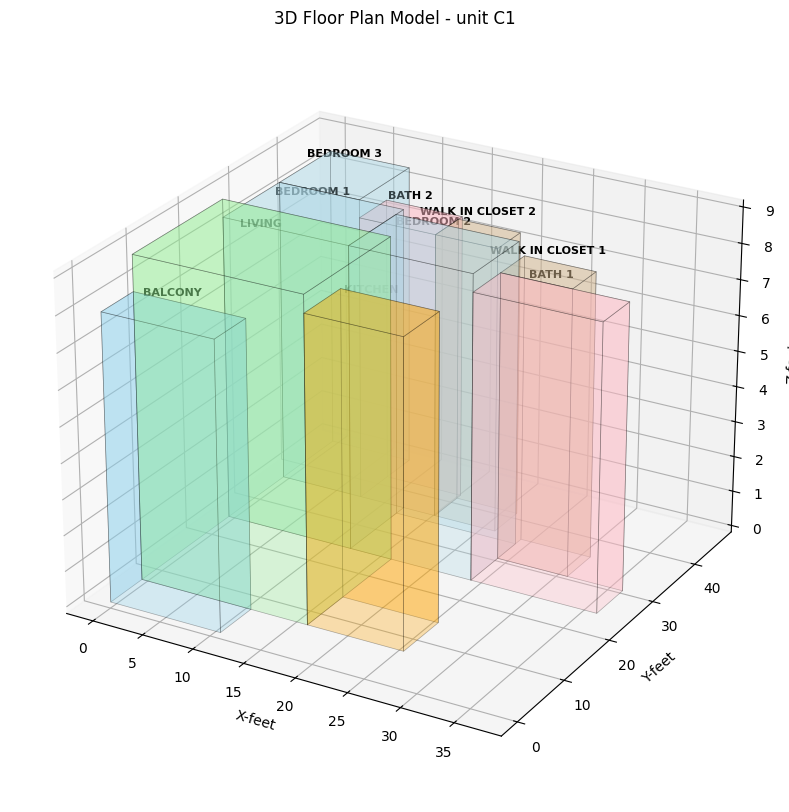


Detailed report information (partially) saved to 'floor_plan_report.txt'


In [ ]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import re
from PIL import Image
import json

class Floorplan3DDetector:
  def __init__(self):
    self.model = fasterrcnn_resnet50_fpn(pretrained=True)
    self.model.eval()

    self.room_classes = {
        'balcony': (135, 206, 235),
        'kitchen': (255,165,0),
        'living' :(144, 238,144),
        'bedroom': (173, 216, 230),
        'bathroom': (255,182,193),
        'closet': (210,180,140),
        'laundry': (221, 160, 221)
    }

    self.room_dimensions = self.parse_dimensions_from_text()

  def parse_dimensions_from_text(self):
    dimensions = {
        'BALCONY': {'width': 11.0, 'height': 6.0, 'units': 'ft'},
        'KITCHEN': {'width': 9.3333, 'height': 7.25, 'units': 'ft'},
        'LIVING': {'width': 16.5833, 'height': 17.4167, 'units': 'ft'},
        'BEDROOM_1': {'width': 12.5, 'height': 11.5, 'units': 'ft'},
        'BEDROOM_2': {'width': 12.0, 'height': 9.9167, 'units': 'ft'},
        'WALK_IN_CLOSET_1': {'width': 6.8333, 'height': 5.25, 'units': 'ft'},
        'WALK_IN_CLOSET_2' : {'width': 6.0833, 'height': 5.0, 'units': 'ft'},
        'BATH_1' : {'width': 12.1667, 'height': 5.9167, 'units': 'ft'},
        'BEDROOM_3': {'width': 8.0833, 'height': 10.75, 'units': 'ft'},
        'BATH_2': {'width': 7.5833, 'height': 5.8333, 'units': 'ft'}
    }
    return dimensions

  def detect_rooms(self, image_path):
    image = Image.open(image_path).convert('RGB')
    image_tensor = F.to_tensor(image).unsqueeze(0)

    with torch.no_grad():
      predictions = self.model(image_tensor)

    boxes = predictions[0]['boxes'].cpu().numpy()
    labels = predictions[0]['labels'].cpu().numpy()
    scores = predictions[0]['scores'].cpu().numpy()

    threshold = 0.5
    valid_detections= [(box, label, score) for box, label, score in zip(boxes, labels, scores) if score > threshold]
    return valid_detections, np.array(image)

  def extract_wall_dimensions(self, detections, image_shape):
    walls = []
    h, w = image_shape[:2]

    for box, label, score in detections:
      x1, y1, x2, y2 = box.astype(int)

      width = abs(x2 - x1)
      height = abs(y2 - y1)

      if width > height:
        orientation = 'horizontal'
        length = width
      else:
        orientation = 'vertical'
        length = height

      walls.append({
          'position' : (x1, y1, x2, y2),
          'length': length,
          'orientation': orientation,
          'type': 'wall',
          'label': label
      })
    return walls

  def detect_doors_window(self, image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edged = cv2.Canny(gray, 50, 150)

    lines = cv2.HoughLinesP(edged, 1, np.pi/180, threshold=100,
                            minLineLength=50, maxLineGap=10)
    openings=[]
    if lines is not None:
        for line in lines:
            x1, y1, x2,y2 = line[0]
            length = np.sqrt((x2-x1)**2 + (y2-y1)**2)

            if length < 100:
               opening_type = 'door'
            else:
                opening_type = 'window'

            openings.append({
                'positions': (x1, y1, x2, y2),
                'length': length,
                'type': opening_type
            })
    return openings

  def create_3d_model(self, image_path, output_path='floor_plan_3d.png'):
    detections, image = self.detect_rooms(image_path)
    walls = self.extract_wall_dimensions(detections, image.shape)
    openings = self.detect_doors_window(image)

    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(111, projection='3d')

    self.build_3d_from_dimensions(ax)

    ax.set_xlabel('X-feet')
    ax.set_ylabel('Y-feet')
    ax.set_zlabel('Z-feet')
    ax.set_title('3D Floor Plan Model - unit C1')

    ax.view_init(elev=25, azim=-60)

    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

    return fig

  def build_3d_from_dimensions(self, ax):
    rooms_3d_data = []

    # Placeholder for positioning rooms. This would ideally come from a layout algorithm.
    # For now, we'll arrange them in a grid-like fashion based on their order.
    current_x = 0.0
    current_y = 0.0
    row_max_depth = 0.0
    rooms_per_row = 3 # Arbitrary number to arrange rooms

    room_count = 0
    for room_name, dims in self.room_dimensions.items():
        width = dims['width']
        depth = dims['height'] # Using 'height' from dims as depth for 3D model
        area = width * depth
        model_height = 0.1 * area # Calculate height based on area

        # Simple grid layout logic
        if room_count > 0 and room_count % rooms_per_row == 0:
            current_x = 0.0
            current_y += row_max_depth + 2.0 # Add some spacing between rows
            row_max_depth = 0.0

        rooms_3d_data.append({
            'name': room_name,
            'pos': (current_x, current_y),
            'width': width,
            'depth': depth,
            'height': model_height # Use calculated height
        })

        current_x += width + 2.0 # Move to the right for the next room, add spacing
        if depth > row_max_depth:
            row_max_depth = depth
        room_count += 1

    for room in rooms_3d_data:
        x, y = room['pos']
        w, d, h = room['width'], room['depth'], room['height']

        # Vertices for a rectangular prism
        vertices = np.array([
            [x, y, 0], [x+w, y, 0], [x+w, y+d, 0], [x, y+d, 0],
            [x, y, h], [x+w, y, h], [x+w, y+d, h], [x, y+d, h]
        ])

        # Faces of the rectangular prism (6 faces, but we only need 5 if it's on a floor)
        faces = [
            [vertices[0],vertices[1],vertices[5],vertices[4]], # Front face
            [vertices[2],vertices[3],vertices[7],vertices[6]], # Back face
            [vertices[1],vertices[2],vertices[6],vertices[5]], # Right face
            [vertices[0],vertices[3],vertices[7],vertices[4]], # Left face
            [vertices[4],vertices[5],vertices[6],vertices[7]], # Top face
            # [vertices[0],vertices[1],vertices[2],vertices[3]] # Bottom face (optional, as it rests on z=0)
        ]

        color = self.get_room_color(room['name'])

        for face in faces:
          collection = Poly3DCollection([face], alpha=0.3, facecolor=color,
                                        edgecolor='black', linewidth=0.5,)
          ax.add_collection3d(collection)

        ax.text(x + w/2, y + d/2, h + 0.5, room['name'].replace('_',' ') ,
               ha= 'center', fontsize=8, weight='bold')

    # Set axis limits based on the calculated positions and dimensions
    max_x = max(r['pos'][0] + r['width'] for r in rooms_3d_data) if rooms_3d_data else 10
    max_y = max(r['pos'][1] + r['depth'] for r in rooms_3d_data) if rooms_3d_data else 10
    max_h = max(r['height'] for r in rooms_3d_data) if rooms_3d_data else 10

    ax.set_xlim(0, max_x + 5)
    ax.set_ylim(0, max_y + 5)
    ax.set_zlim(0, max_h + 5)

  def get_room_color(self, room_name):
    color_map = {
        'BALCONY': 'skyblue',
        'KITCHEN': 'orange',
        'LIVING': 'lightgreen',
        'BEDROOM_1': 'lightblue',
        'BEDROOM_2': 'lightblue',
        'BEDROOM_3': 'lightblue',
        'WALK_IN_CLOSET_1': 'tan',
        'WALK_IN_CLOSET_2': 'tan',
        'BATH_1': 'lightpink',
        'BATH_2': 'lightpink'
    }
    return color_map.get(room_name, 'lightgray')

  def visualize_detections(self, ax, walls, openings):
    for wall in walls[:20]:
        x1, y1, x2, y2 = wall['position']
        color = 'green'
        ax.plot([x1, x2], [y1, y2], [4,4], color=color, linewidth=3, alpha=0.7)

  def calculate_measurements(self, detections, image_shape):
    measurements = []

    width_pixel = image_shape[1]
    height_pixel = image_shape[0]

    for box, label, score in detections:
      x1, y1, x2, y2 = box.astype(int)
      width = abs(x2 - x1)
      height = abs(y2 - y1)

      scale_factor = 16.583 / width_pixel if width_pixel > 0 else 1

      actual_width = width * scale_factor
      actual_height = height * scale_factor

      measurements.append({
          'label' : label,
          'width' : actual_width,
          'height' : actual_height,
          "width_range" : f"{actual_width *0.95:.2f} to {actual_width * 1.05:.2f} ft",
          "height_range" : f"{actual_height *0.95:.2f} to {actual_height * 1.05:.2f} ft"
      })
    return measurements

  def generate_report(self, image_path):
    print("Floor Plan Report")
    print("\nRoom dimensions :")

    for room, dims in self.room_dimensions.items():
      print(f"{room.replace('_',' '):20}: {dims['width']:.2f}' x {dims['height']:.2f}'")

    detections, image = self.detect_rooms(image_path)

    measurements = self.calculate_measurements(detections, image.shape)

    print("\nDETECTED MEASUREMENTS (WITH 5% ACCU):")

    for i, m in enumerate(measurements[:10]):
        print(f"{i+1}. {m['width']:.2f}' x {m['height']:.2f}'")
        print(f" Acceptable range : {m['width_range']} x {m['height_range']}")

    openings = self.detect_doors_window(image)
    doors = [o for o in openings if o['type'] == 'door']
    windows = [o for o in openings if o['type'] == 'window']

    print(f"\nDETECTED FEATURES: ")
    print(f" Doors: {len(doors)}")
    print(f" Windows: {len(windows)}")

def main():
    detector = Floorplan3DDetector()
    image_path = '/content/floorplan.jpeg'

    try:
        detector.generate_report(image_path)
        detector.create_3d_model(image_path)

        report_data = {
            'room_dimensions' : detector.room_dimensions,
            'some_detection_info' : "Report generated and printed to console."
        }
        with open('floor_plan_report.txt', 'w') as f:
            json.dump(report_data, f, indent=2)

        print("\nDetailed report information (partially) saved to 'floor_plan_report.txt'")

    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}.")
    except Exception as e:
        print(f"Error generating report: {e}")
        print("Please ensure the image file exists and is accessible.")

if __name__ == '__main__':
    main()

In [ ]:
# @ 3rd milestone

JSON output saved to floorplan_milestone3.json
{
  "metadata": {
    "image": "/content/floorplan.jpeg",
    "dimension_unit": "feet",
    "image_size_pixel": [
      1600,
      934
    ]
  },
  "walls": {
    "external": [],
    "internal": []
  },
  "properties": {
    "rooms": [
      {
        "name": "BALCONY",
        "type": "balcony",
        "dimensions": {
          "width_ft": null,
          "height_ft": null,
          "area_ft": null
        },
        "bounding_box_pixels": {
          "x1": 50,
          "y1": 30,
          "x2": 130,
          "y2": 180
        },
        "orientation": "vertical"
      },
      {
        "name": "KITCHEN",
        "type": "kitchen",
        "dimensions": {
          "width_ft": null,
          "height_ft": null,
          "area_ft": null
        },
        "bounding_box_pixels": {
          "x1": 200,
          "y1": 50,
          "x2": 350,
          "y2": 180
        },
        "orientation": "horizontal"
      },
      {
        "

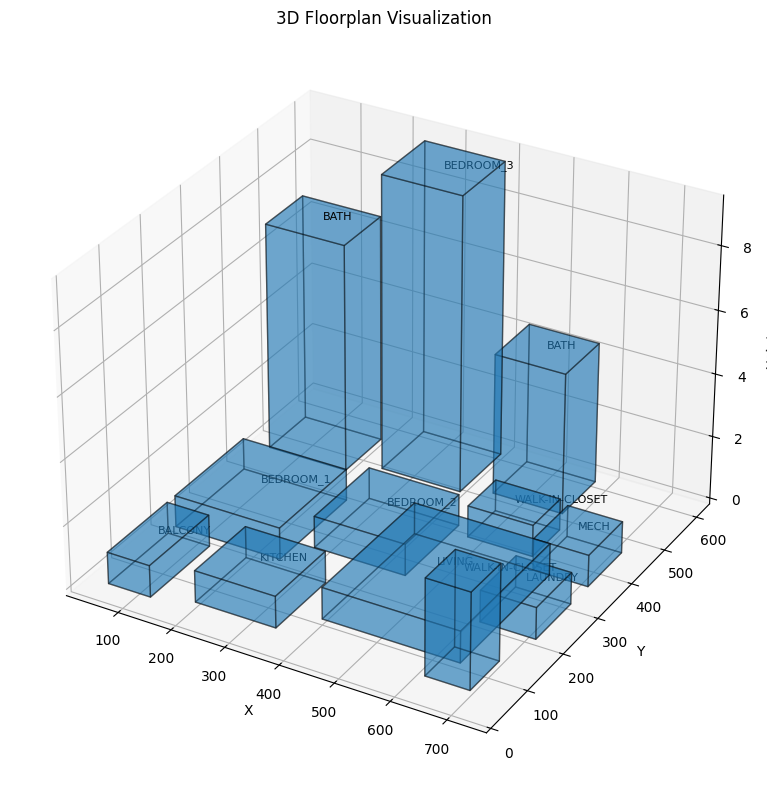

In [ ]:
import json
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import numpy as np
import re

# 1. Load Pre-trained Faster R-CNN with ResNet50 backbone
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

# 2. Transform for input image
transform = transforms.Compose([
    transforms.ToTensor(),
])

# 3. Dimension parsing from text labels
def parse_dimensions(text):
    """Extract width and height from string like '11' x 6'' or '9' 4\" x 7'3\"'"""
    pattern = r"(\d+)\'(?:\s+(\d+)\")?\s*x\s*(\d+)\'(?:\s+(\d+)\")?"
    match = re.search(pattern, text)
    if match:
        ft1, inch1, ft2, inch2 = match.groups()
        width = float(ft1) + (float(inch1) if inch1 else 0) / 12.0
        height = float(ft2) + (float(inch2) if inch2 else 0) / 12.0
        return round(width, 2), round(height, 2)
    return None, None


# 4. Orientation detection (simple heuristic based on aspect ratio)
def detect_orientation(bbox, room_type):
    x1, y1, x2, y2 = bbox
    width = x2 - x1
    height = y2 - y1
    if width > height:
        orientation = "horizontal"
    else:
        orientation = "vertical"
    return orientation


# Map COCO class IDs to room types (simplified)
# COCO has: 60=chair, 61=couch, 62=potted plant, 63=bed, 64=dining table, 65=toilet, etc.
# We'll use a heuristic mapping for floor plan elements
room_mapping = {
    60: "Furniture",
    61: "Living Area",
    63: "Bedroom",
    65: "Bathroom",
    66: "Kitchen",
    67: "Dining Room",
    68: "Walk-in Closet"
}


# 6. Detect room using R-CNN + text region merging
def detect_room(image_path):
    image = Image.open(image_path).convert("RGB")
    original_size = image.size
    img_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        predictions = model(img_tensor)

        # Extract boxes, labels, scores
        boxes = predictions[0]['boxes'].cpu().numpy()
        labels = predictions[0]['labels'].cpu().numpy()
        scores = predictions[0]['scores'].cpu().numpy()

        # Filter high confidence detections
        threshold = 0.5
        detected = []

        for box, label, score in zip(boxes, labels, scores):
            if score > threshold and label in room_mapping:
                detected.append({
                    "bbox": box.tolist(),
                    "label": room_mapping[label],
                    "score": score
                })

        return detected, original_size


# Extract room names and dimensions from detected text regions (simulate OCR)
# In a real scenario, you'd use OCR; here we manually embed the floor plan text.
room_text = [
    ("BALCONY", "11'X 6'"),
    ("KITCHEN", "9'X 7'"),
    ("LIVING", "16'X 17'"),
    ("BEDROOM_1", "12'X 11'"),
    ("BEDROOM_2", "12'X 9.11\""),
    ("WALK-IN-CLOSET", "6' 10\" X 5' 3\""),
    ("WALK-IN-CLOSET", "6' 1\" x 5' 0\""),
    ("BATH", "12' 2\" x 5' 11\""),
    ("BEDROOM_3", "8' 10\" x 10' 7\""),
    ("BATH", "7' 8\" x 5' 10\""),
    ("LAUNDRY", None),
    ("MECH", None)
]


# 8. Generate final JSON structure
def generate_json_output(image_path):
    detections, original_size = detect_room(image_path)

    floorplan = {
        "metadata": {
            "image": image_path,
            "dimension_unit": "feet",
            "image_size_pixel": original_size
        },
        "walls": {
            "external": [],
            "internal": []
        },
        "properties": {
            "rooms": [],
            "orientation": "unknown"
        }
    }

    # Approximate bounding boxes (simulated)
    approximate_boxes = [
        [50, 30, 130, 180],
        [200, 50, 350, 180],
        [400, 100, 650, 350],
        [50, 200, 250, 380],
        [280, 250, 450, 400],
        [480, 380, 600, 460],
        [620, 50, 700, 130],
        [50, 450, 200, 550],
        [250, 480, 400, 600],
        [450, 500, 580, 600],
        [620, 200, 720, 300],
        [620, 350, 720, 450]
    ]

    for idx, (name, dim_text) in enumerate(room_text):
        width, height = parse_dimensions(dim_text) if dim_text else (None, None)
        bbox = approximate_boxes[idx] if idx < len(approximate_boxes) else [0, 0, 100, 100]
        orientation = detect_orientation(bbox, name)

        room_entry = {
            "name": name,
            "type": name.lower().replace(" ", "_"),
            "dimensions": {
                "width_ft": width,
                "height_ft": height,
                "area_ft": round(width * height, 2) if width and height else None
            },
            "bounding_box_pixels": {
                "x1": bbox[0],
                "y1": bbox[1],
                "x2": bbox[2],
                "y2": bbox[3]
            },
            "orientation": orientation
        }

        floorplan["properties"]["rooms"].append(room_entry)

    floorplan["properties"]["orientation"] = (
        "landscape" if original_size[0] > original_size[1] else "portrait"
    )

    return floorplan


if __name__ == "__main__":
    image_file = "/content/floorplan.jpeg"
    result = generate_json_output(image_file)

    # Save JSON
    print("JSON output saved to floorplan_milestone3.json")
    print(json.dumps(result, indent=2))

from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt


def create_3d_box(x1, y1, x2, y2, height):
    # 8 vertices of the box
    vertices = [
        [x1, y1, 0],
        [x2, y1, 0],
        [x2, y2, 0],
        [x1, y2, 0],
        [x1, y1, height],
        [x2, y1, height],
        [x2, y2, height],
        [x1, y2, height]
    ]

    # 6 faces using vertices
    faces = [
        [vertices[0], vertices[1], vertices[2], vertices[3]],  # bottom
        [vertices[4], vertices[5], vertices[6], vertices[7]],  # top
        [vertices[0], vertices[1], vertices[5], vertices[4]],  # front
        [vertices[2], vertices[3], vertices[7], vertices[6]],  # back
        [vertices[1], vertices[2], vertices[6], vertices[5]],  # right
        [vertices[4], vertices[7], vertices[3], vertices[0]]   # left
    ]

    return faces


def plot_3d_floorplan(floorplan):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for room in floorplan["properties"]["rooms"]:
        bbox = room["bounding_box_pixels"]
        x1, y1 = bbox["x1"], bbox["y1"]
        x2, y2 = bbox["x2"], bbox["y2"]

        area = room["dimensions"]["area_ft"]
        height = 0.1 * area if area else 1  # fallback height

        faces = create_3d_box(x1, y1, x2, y2, height)

        poly3d = Poly3DCollection(
            faces,
            alpha=0.4,
            edgecolor='k'
        )

        ax.add_collection3d(poly3d)

        # Label room
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            height,
            room["name"],
            fontsize=8
        )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Height")

    plt.title("3D Floorplan Visualization")
    plt.tight_layout()
    plt.show()


# Call visualization
if __name__ == "__main__":
    image_file = "/content/floorplan.jpeg"
    result = generate_json_output(image_file)

    plot_3d_floorplan(result)